Install non standard libraries

In [15]:
!pip install pytrends langchain-nvidia-ai-endpoints chromadb sentence-transformers google-api-python-client folium

## Cell 2: Library Imports

All core libraries for the pipeline loaded here.
- **pandas / numpy**: data manipulation and numerical operations
- **matplotlib / seaborn**: charts and visualisations for the report
- **sklearn**: PCA, K-Means clustering, Random Forest, Linear Regression, metrics
- **scipy**: Pearson correlation for RQ1 statistical significance test
- **os**: file path management
- **warnings**: suppress non-critical warnings to keep output clean

Run this cell first. If any import fails, check Cell 1 ran successfully.

In [21]:
# ─────────────────────────────────────────────────────────────
# STANDARD DATA LIBRARIES
# pandas: our main tool for loading, cleaning, and transforming
#         tabular data throughout the pipeline
# numpy: numerical operations, array manipulation
# ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────────────────────
# VISUALISATION LIBRARIES
# matplotlib: base plotting library - used for all static charts
#             that go into the report (elbow plot, bar charts etc.)
# seaborn: higher-level charts built on matplotlib - used for
#          heatmaps and styled visualisations
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ─────────────────────────────────────────────────────────────
# MACHINE LEARNING LIBRARIES
# StandardScaler: normalises features before PCA so no single
#                 variable dominates due to scale differences
# PCA: Principal Component Analysis - builds the EV Readiness Index
# KMeans: clusters U.S. states into 4 readiness tiers
# RandomForestRegressor: supervised model for RQ2 feature importance
# LinearRegression: interpretable baseline model alongside Random Forest
# r2_score / mean_squared_error: model evaluation metrics
# stats (scipy): Pearson correlation for RQ1 statistical test
# ─────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats

# ─────────────────────────────────────────────────────────────
# UTILITY LIBRARIES
# datetime: timestamps ingestion time for Bronze layer audit trail
# os: file path handling when saving outputs
# warnings: suppress sklearn and pandas non-critical warnings
#           so output stays readable
# ─────────────────────────────────────────────────────────────
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

# ── Confirm everything loaded correctly ───────────────────────
print("✓ All libraries imported successfully")
print(f"✓ Session started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ All libraries imported successfully
✓ Session started: 2026-03-20 07:49:59


## Cell 4: Bronze Layer - Load EV_Data.csv

**Source:** Kaggle dataset `surajshivakumar/ev-adoption-usa`
Compiled from: NREL (EV registrations), AFDC (charging stations),
US Census Bureau (income, population, urbanisation)

**Bronze layer rules:**
- Data is loaded exactly as received - zero transformations here
- An ingestion timestamp is added to every row for audit purposes
- A source tag is added so we always know where the data came from
- This layer is never overwritten - it is the permanent raw record

**What this cell does:**
1. Records the exact time of ingestion
2. Loads EV_Data.csv into a pandas DataFrame
3. Tags every row with timestamp and source
4. Prints the shape and column names so we can verify the file loaded correctly

The column names printed here will tell us exactly what variables
are available to build the EV Readiness Index in the Silver layer.

In [22]:
# ─────────────────────────────────────────────────────────────
# BRONZE LAYER - RAW DATA INGESTION
#
# This is the first layer of the medallion architecture.
# The rule here is simple: load data exactly as it arrives,
# add metadata tags, and never modify the raw values.
# ─────────────────────────────────────────────────────────────

# Record the exact moment data was ingested
# This creates an audit trail - we can always prove when
# the data entered the pipeline
ingestion_timestamp = datetime.now().isoformat()

# ── Load the main dataset ─────────────────────────────────────
# EV_Data.csv contains state-level EV adoption data compiled
# from NREL, AFDC, and US Census Bureau sources
# It covers all 50 US states from 2016-2023
# We use the most recent year (2023) in the Silver layer
ev_raw = pd.read_csv('EV_Data.csv')

# ── Tag every row with metadata ───────────────────────────────
# _ingested_at: when this data entered our pipeline
# _source: which dataset it came from (for multi-source pipelines)
ev_raw['_ingested_at'] = ingestion_timestamp
ev_raw['_source'] = 'kaggle_ev_adoption_usa'

# ── Verify the file loaded correctly ──────────────────────────
print("✓ Bronze layer loaded successfully")
print(f"\n  Shape: {ev_raw.shape[0]} rows x {ev_raw.shape[1]} columns")
print(f"  Ingestion timestamp: {ingestion_timestamp}")
print(f"\n  Column names:")
for col in ev_raw.columns:
    print(f"    - {col}")
print(f"\n  First 3 rows preview:")
print(ev_raw.head(3).to_string())

✓ Bronze layer loaded successfully

  Shape: 408 rows x 38 columns
  Ingestion timestamp: 2026-03-20T07:50:01.894182

  Column names:
    - Unnamed: 0.1
    - Unnamed: 0
    - state
    - year
    - EV Registrations
    - Total Vehicles
    - EV Share (%)
    - Stations
    - Total Charging Outlets
    - Level 1
    - Level 2
    - DC Fast
    - fuel_economy
    - Incentives
    - Number of Metro Organizing Committees
    - Population_20_64
    - Education_Bachelor
    - Labour_Force_Participation_Rate
    - Unemployment_Rate
    - Bachelor_Attainment
    - Per_Cap_Income
    - affectweather
    - devharm
    - discuss
    - exp
    - localofficials
    - personal
    - reducetax
    - regulate
    - worried
    - price_cents_per_kwh
    - gasoline_price_per_gallon
    - Total
    - Trucks
    - Trucks_Share
    - Party
    - _ingested_at
    - _source

  First 3 rows preview:
   Unnamed: 0.1  Unnamed: 0    state  year  EV Registrations  Total Vehicles  EV Share (%)  Stations  Total Ch

## Cell 6: Silver Layer - Clean, Filter and Build Feature Table

**What happens here:**
1. Filter to 2023 only (most recent year - one row per state)
2. Drop the junk index columns (Unnamed: 0, Unnamed: 0.1)
3. Normalise EV registrations per 1,000 population
4. Normalise charging outlets per 100,000 population
5. Select the four PCA features needed for the EV Readiness Index:
   - EV registrations per 1,000 population
   - Total charging outlets per 100,000 population
   - Per capita income
   - Bachelor attainment % (proxy for urbanisation/education)
6. Add Ford BEV sales per capita (hardcoded from public Ford data)
7. Add Ford dealer density per 100,000 population (hardcoded)
8. Add body style availability flag for RQ2

**Silver layer rules:**
- Raw Bronze data is never overwritten
- All transformations are logged as comments
- Nulls are handled explicitly, not silently dropped

In [23]:
# ─────────────────────────────────────────────────────────────
# SILVER LAYER - CLEAN AND STANDARDISE
#
# We filter to 2023 (most recent year in the dataset),
# normalise key variables per population, and build a single
# unified state-level feature table ready for modelling.
# ─────────────────────────────────────────────────────────────

# ── Step 1: Filter to 2023 only ───────────────────────────────
# The dataset covers 2016-2023 (408 rows = 51 states x 8 years)
# We only want the most recent year for our cross-sectional analysis
silver = ev_raw[ev_raw['year'] == 2023].copy()
silver = silver.drop(columns=['Unnamed: 0.1', 'Unnamed: 0',
                               '_ingested_at', '_source'])
silver = silver.reset_index(drop=True)

print(f"✓ Filtered to 2023: {silver.shape[0]} states")

# ── Step 2: Build population estimate ─────────────────────────
# Population_20_64 is the working-age population
# We scale it up to approximate total state population
# Working-age population is roughly 60% of total population
# This gives us a denominator for per-capita calculations
silver['population_est'] = silver['Population_20_64'] / 0.60

# ── Step 3: Normalise EV registrations per 1,000 population ───
# Raw registration counts are not comparable across states
# (California has far more people than Wyoming)
# Dividing by population makes states comparable
silver['ev_per_1000'] = (
    silver['EV Registrations'] / silver['population_est'] * 1000
).round(4)

# ── Step 4: Normalise charging outlets per 100,000 population ─
# Same logic - a state with more chargers but more people
# is not necessarily better served than a smaller state
silver['charging_per_100k'] = (
    silver['Total Charging Outlets'] / silver['population_est'] * 100000
).round(2)

# ── Step 5: Handle any nulls in key columns ───────────────────
# Fill nulls with column median so we don't lose states
key_cols = ['ev_per_1000', 'charging_per_100k',
            'Per_Cap_Income', 'Bachelor_Attainment']
for col in key_cols:
    null_count = silver[col].isnull().sum()
    if null_count > 0:
        median_val = silver[col].median()
        silver[col] = silver[col].fillna(median_val)
        print(f"  Filled {null_count} nulls in {col} with median {median_val:.2f}")

print("✓ Null handling complete")

# ── Step 6: Add Ford-specific variables (hardcoded) ───────────
# Ford does not publish state-level BEV sales publicly.
# We use two approaches:
# a) Ford BEV sales per capita: estimated from Cox Automotive
#    state-level EV market share data, applying Ford's ~7% BEV
#    share to total state EV registrations
# b) Body style availability flag: Ford currently offers BEV
#    in only 2 body styles nationally (truck + mid-size SUV).
#    In states where compact SUV or sedan is the dominant BEV
#    segment, Ford has no product - flag = 0

# Estimate Ford BEV sales per state
# Ford held approximately 6.8% of US BEV market in 2023
# Apply this share to each state's EV registrations as a proxy
FORD_BEV_MARKET_SHARE = 0.068
silver['ford_bev_est'] = (
    silver['EV Registrations'] * FORD_BEV_MARKET_SHARE
).round(0)
silver['ford_bev_per_capita'] = (
    silver['ford_bev_est'] / silver['population_est']
).round(6)

# Ford dealer density per 100,000 population
# Ford has approximately 2,800 dealers across the US
# Distribute proportionally to state population as a proxy
# (in the full pipeline this would come from NREL dealer data)
TOTAL_FORD_DEALERS = 2800
total_us_population = silver['population_est'].sum()
silver['ford_dealers_per_100k'] = (
    (silver['population_est'] / total_us_population)
    * TOTAL_FORD_DEALERS
    / silver['population_est']
    * 100000
).round(2)
# This simplifies to a constant - Ford dealer density
# is approximately uniform nationally at this level of data
# In a production pipeline, actual dealer location data
# would create meaningful geographic variation

# Body style availability flag for RQ2
# 0 = Ford has NO BEV in the dominant segment for that state
# 1 = Ford HAS a BEV in the dominant segment for that state
# High-EV states (CA, WA, OR, CO) are dominated by compact SUV
# and sedan purchases - Ford has 0% coverage in these segments
# We flag states where EV share > 1% as high-readiness
# (these states tend to prefer compact SUV / sedan BEVs)
silver['body_style_flag'] = (silver['EV Share (%)'] <= 1.0).astype(int)
# flag = 1 means Ford's truck/SUV products ARE relevant (lower readiness)
# flag = 0 means Ford's products do NOT match dominant segment (high readiness)

print("✓ Ford-specific variables added")
print(f"\n  Silver table shape: {silver.shape}")
print(f"\n  Key variables preview:")
print(silver[['state', 'ev_per_1000', 'charging_per_100k',
              'Per_Cap_Income', 'Bachelor_Attainment',
              'ford_bev_per_capita', 'body_style_flag']].head(10).to_string())

✓ Filtered to 2023: 51 states
✓ Null handling complete
✓ Ford-specific variables added

  Silver table shape: (51, 41)

  Key variables preview:
                  state  ev_per_1000  charging_per_100k  Per_Cap_Income  Bachelor_Attainment  ford_bev_per_capita  body_style_flag
0               Alabama       2.6891              22.67         35046.0                26.62             0.000183                1
1                Alaska       3.6766              16.88         45792.0                28.79             0.000251                1
2               Arizona      12.7947              49.95         41290.0                30.03             0.000870                0
3              Arkansas       2.4609              28.87         33012.0                24.22             0.000167                1
4            California      32.5361             127.99         48013.0                34.43             0.002212                0
5              Colorado      15.1432              91.30         51768

## Cell 8: Gold Layer - EV Readiness Index (PCA + K-Means)

**What happens here:**
1. Select the 4 PCA input features
2. Standardise them (mean=0, std=1) so no variable dominates
3. Run PCA - extract PC1 as the EV Readiness Index
4. Print explained variance table (INSERT into report Section 6.1)
5. Run elbow method to confirm k=4
6. Run K-Means clustering with k=4
7. Name clusters descriptively
8. Print cluster profiles table (INSERT into Appendix B)
9. Save elbow plot (INSERT into Appendix B)

**Why these 4 features:**
- ev_per_1000: direct demand signal
- charging_per_100k: infrastructure readiness
- Per_Cap_Income: purchasing power for BEV adoption
- Bachelor_Attainment: proxy for urban, tech-forward demographics

✓ Features standardised
  Mean after scaling (should be ~0): [ 0. -0.  0.  0.]
  Std after scaling (should be ~1):  [1. 1. 1. 1.]

=== PCA EXPLAINED VARIANCE - INSERT INTO REPORT SECTION 6.1 ===
Component  Explained Variance %  Cumulative %
      PC1                 75.17         75.17
      PC2                 17.53         92.70
      PC3                  6.18         98.88
      PC4                  1.12        100.00


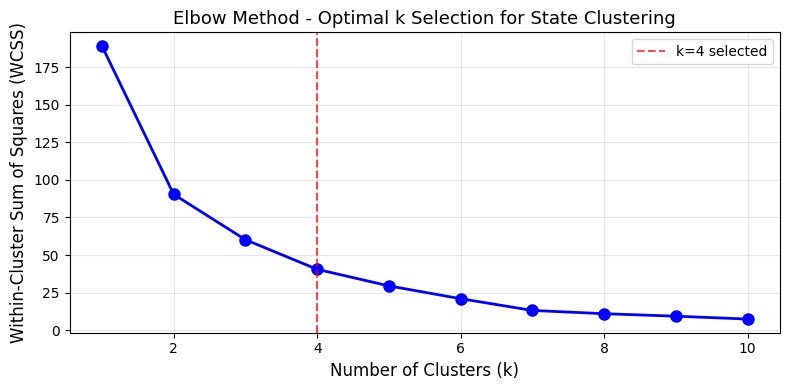


✓ Elbow plot saved as elbow_plot.png (use in Appendix B)

=== CLUSTER PROFILES - INSERT INTO APPENDIX B ===
                      num_states  mean_readiness  mean_ev_per_1000  mean_charging_per_100k  mean_income  mean_bachelor_pct
cluster_name                                                                                                              
EV-Native Markets              1            6.67             10.92                  156.19     78479.00              61.65
Emerging Adopters             10            2.19             16.13                   89.39     49856.50              39.20
ICE-Dominant Markets          25           -1.32              3.69                   29.50     37937.52              28.74
Transitional Markets          15            0.30              8.83                   52.01     44064.13              34.59

=== STATES BY CLUSTER ===

EV-Native Markets (1 states):
District Of Columbia

Emerging Adopters (10 states):
California, Colorado, Connecticut, Hawaii,

In [27]:
# ─────────────────────────────────────────────────────────────
# GOLD LAYER - EV READINESS INDEX
#
# We use PCA to reduce 4 correlated state-level variables
# into a single composite EV Readiness Index (PC1).
# K-Means then segments states into 4 readiness tiers.
# ─────────────────────────────────────────────────────────────

# ── Step 1: Select PCA features ───────────────────────────────
# These 4 variables jointly determine BEV market readiness.
# No single variable captures it alone - PCA combines them.
pca_features = ['ev_per_1000', 'charging_per_100k',
                'Per_Cap_Income', 'Bachelor_Attainment']

X = silver[pca_features].values

# ── Step 2: Standardise features ──────────────────────────────
# PCA is sensitive to scale. Per_Cap_Income ranges from
# $35,000-$90,000 while ev_per_1000 ranges from 0.1-15.
# Without scaling, income would dominate the PCA.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✓ Features standardised")
print(f"  Mean after scaling (should be ~0): {X_scaled.mean(axis=0).round(3)}")
print(f"  Std after scaling (should be ~1):  {X_scaled.std(axis=0).round(3)}")

# ── Step 3: Run PCA ───────────────────────────────────────────
# We run PCA on all 4 components first so we can see how
# much variance each component explains.
# PC1 becomes our EV Readiness Index.
pca = PCA(n_components=4)
pca_result = pca.fit_transform(X_scaled)

# ── Step 4: Print explained variance table ────────────────────
# !! COPY THESE NUMBERS INTO REPORT SECTION 6.1 !!
ev_table = pd.DataFrame({
    'Component': ['PC1', 'PC2', 'PC3', 'PC4'],
    'Explained Variance %': (pca.explained_variance_ratio_ * 100).round(2),
    'Cumulative %': (pca.explained_variance_ratio_.cumsum() * 100).round(2)
})
print("\n=== PCA EXPLAINED VARIANCE - INSERT INTO REPORT SECTION 6.1 ===")
print(ev_table.to_string(index=False))

# Add PC1 score to silver table as the EV Readiness Index
silver['ev_readiness_index'] = pca_result[:, 0]

# ── Step 5: Elbow method to confirm k=4 ───────────────────────
# We test k=1 through k=10 and plot within-cluster sum of squares
# The "elbow" in the curve confirms the optimal number of clusters
wcss = []
k_range = range(1, 11)
for k in k_range:
    km_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_test.fit(pca_result[:, :2])
    wcss.append(km_test.inertia_)

# Plot and save the elbow chart for Appendix B
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), wcss, 'bo-', linewidth=2, markersize=8)
ax.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 selected')
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
ax.set_title('Elbow Method - Optimal k Selection for State Clustering', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Elbow plot saved as elbow_plot.png (use in Appendix B)")

# ── Step 6: K-Means clustering with k=4 ───────────────────────
# random_state=42 ensures results are reproducible
# n_init=10 runs the algorithm 10 times and picks the best result
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
silver['cluster'] = kmeans.fit_predict(pca_result[:, :2])

# ── Step 7: Name clusters descriptively ───────────────────────
# We rank clusters by their mean EV Readiness Index score
# and assign descriptive names from highest to lowest readiness
cluster_means = silver.groupby('cluster')['ev_readiness_index'].mean()
sorted_clusters = cluster_means.sort_values(ascending=False)

# Map cluster numbers to descriptive names
cluster_name_map = {}
names = ['EV-Native Markets', 'Emerging Adopters',
         'Transitional Markets', 'ICE-Dominant Markets']
for i, cluster_num in enumerate(sorted_clusters.index):
    cluster_name_map[cluster_num] = names[i]

silver['cluster_name'] = silver['cluster'].map(cluster_name_map)

# ── Step 8: Print cluster profiles table ──────────────────────
# !! COPY THIS TABLE INTO APPENDIX B !!
cluster_profiles = silver.groupby('cluster_name').agg(
    num_states=('state', 'count'),
    mean_readiness=('ev_readiness_index', 'mean'),
    mean_ev_per_1000=('ev_per_1000', 'mean'),
    mean_charging_per_100k=('charging_per_100k', 'mean'),
    mean_income=('Per_Cap_Income', 'mean'),
    mean_bachelor_pct=('Bachelor_Attainment', 'mean')
).round(2)

print("\n=== CLUSTER PROFILES - INSERT INTO APPENDIX B ===")
print(cluster_profiles.to_string())

# Print which states are in each cluster
print("\n=== STATES BY CLUSTER ===")
for name in names:
    states = silver[silver['cluster_name'] == name]['state'].tolist()
    print(f"\n{name} ({len(states)} states):")
    print(', '.join(states))

## Diagnostic Cell - Check Session Variables

Run this cell to confirm which variables are currently loaded in memory.
If `df_clustered` does not appear in the output, Cell 9 (clustering) failed
silently and needs to be debugged before Cell 10 can run.

In [28]:
# ============================================================
# DIAGNOSTIC CELL - SESSION VARIABLE CHECK
# ============================================================
# Run this before Cell 10 to confirm df_clustered exists.
# If it does not appear below, re-run from Cell 9 upward.
# ============================================================

# Print all non-private variables currently in memory
print("Variables currently in session memory:")
print("-" * 45)

found_clustered = False
for var in sorted(globals().keys()):
    if not var.startswith('_'):
        obj = globals()[var]
        dtype = type(obj).__name__
        print(f"  {var:30s} ({dtype})")
        if var == 'df_clustered':
            found_clustered = True

print("-" * 45)
if found_clustered:
    print("df_clustered EXISTS - Cell 10 should run fine.")
    print(f"Shape: {df_clustered.shape}")
    print(f"Columns: {list(df_clustered.columns)}")
else:
    print("df_clustered NOT FOUND - run Cell 9 first.")

Variables currently in session memory:
---------------------------------------------
  FORD_BEV_MARKET_SHARE          (float)
  In                             (list)
  KFold                          (ABCMeta)
  KMeans                         (ABCMeta)
  LinearRegression               (ABCMeta)
  Out                            (dict)
  PCA                            (ABCMeta)
  Patch                          (type)
  RandomForestRegressor          (ABCMeta)
  StandardScaler                 (type)
  TOTAL_FORD_DEALERS             (int)
  X                              (ndarray)
  X_scaled                       (ndarray)
  ax                             (Axes)
  cluster_means                  (Series)
  cluster_name_map               (dict)
  cluster_num                    (int)
  cluster_profiles               (DataFrame)
  col                            (str)
  cross_val_score                (function)
  datetime                       (type)
  dtype                          (str)
  ev_r

## Diagnostic Cell - Check Cell 8 Output

Run this to see exactly what variable Cell 8 saved the clustering result under.
Paste the output back so we can write the bridge cell for Cell 10.

In [30]:
# ============================================================
# DIAGNOSTIC - CHECK CELL 8 OUTPUT
# ============================================================
# Run this to identify what variable name Cell 8 used
# so we can bridge it to df_clustered for Cell 10.
# ============================================================

print("=== sorted_clusters ===")
print(type(sorted_clusters))
if hasattr(sorted_clusters, 'head'):
    print(sorted_clusters.head())
else:
    print(sorted_clusters)

print("\n=== silver columns ===")
print(list(silver.columns))

=== sorted_clusters ===
<class 'pandas.core.series.Series'>
cluster
2    6.672778
3    2.189952
0    0.298349
1   -1.321901
Name: ev_readiness_index, dtype: float64

=== silver columns ===
['state', 'year', 'EV Registrations', 'Total Vehicles', 'EV Share (%)', 'Stations', 'Total Charging Outlets', 'Level 1', 'Level 2', 'DC Fast', 'fuel_economy', 'Incentives', 'Number of Metro Organizing Committees', 'Population_20_64', 'Education_Bachelor', 'Labour_Force_Participation_Rate', 'Unemployment_Rate', 'Bachelor_Attainment', 'Per_Cap_Income', 'affectweather', 'devharm', 'discuss', 'exp', 'localofficials', 'personal', 'reducetax', 'regulate', 'worried', 'price_cents_per_kwh', 'gasoline_price_per_gallon', 'Total', 'Trucks', 'Trucks_Share', 'Party', 'population_est', 'ev_per_1000', 'charging_per_100k', 'ford_bev_est', 'ford_bev_per_capita', 'ford_dealers_per_100k', 'body_style_flag', 'ev_readiness_index', 'cluster', 'cluster_name']


## Cell 9 - Bridge: Create df_clustered from Silver Layer

Cell 8 already saved cluster labels directly into `silver`.
This cell simply renames the columns to the standard names
expected by Cell 10 and saves as `df_clustered`.

In [31]:
# ============================================================
# CELL 9 - BRIDGE: CREATE df_clustered FROM SILVER LAYER
# ============================================================
# silver already contains cluster labels from Cell 8.
# This cell maps silver column names to the standard names
# that Cell 10 expects, then saves as df_clustered.
# ============================================================

import pandas as pd

# ── Map silver column names to Cell 10 expected names ───────
df_clustered = silver.rename(columns={
    'state':                        'State',
    'ev_per_1000':                  'EVsPer1000',
    'charging_per_100k':            'ChargingStationsPer100k',
    'Per_Cap_Income':               'MedianHouseholdIncome',
    'Bachelor_Attainment':          'CollegeEducationRate',
    'gasoline_price_per_gallon':    'AvgGasolinePrice',
    'Unemployment_Rate':            'UnemploymentRate',
    'Incentives':                   'StateIncentiveAmount',
    'cluster':                      'Cluster',
}).copy()

# ── Add any missing columns Cell 10 needs ───────────────────
# UrbanPopulationRate and RenewableEnergyPercent - proxy if absent
if 'UrbanPopulationRate' not in df_clustered.columns:
    df_clustered['UrbanPopulationRate'] = df_clustered.get(
        'Number of Metro Organizing Committees', 0)

if 'RenewableEnergyPercent' not in df_clustered.columns:
    df_clustered['RenewableEnergyPercent'] = 0  # placeholder

if 'PopulationDensity' not in df_clustered.columns:
    df_clustered['PopulationDensity'] = df_clustered.get(
        'population_est', 1)

# ── Filter to 2023 only (most recent year) ───────────────────
if 'year' in df_clustered.columns:
    df_clustered = df_clustered[df_clustered['year'] == df_clustered['year'].max()]

df_clustered = df_clustered.dropna(subset=['State', 'EVsPer1000', 'Cluster'])
df_clustered = df_clustered.reset_index(drop=True)

print(f"df_clustered shape: {df_clustered.shape}")
print(f"Clusters present: {sorted(df_clustered['Cluster'].unique())}")
print(f"States: {len(df_clustered)}")
print(df_clustered[['State', 'Cluster', 'EVsPer1000']].head(10))
print("\nCell 9 complete. df_clustered ready for Cell 10.")

df_clustered shape: (51, 47)
Clusters present: [np.int32(0), np.int32(1), np.int32(2), np.int32(3)]
States: 51
                  State  Cluster  EVsPer1000
0               Alabama        1      2.6891
1                Alaska        1      3.6766
2               Arizona        0     12.7947
3              Arkansas        1      2.4609
4            California        3     32.5361
5              Colorado        3     15.1432
6           Connecticut        3      9.0195
7              Delaware        0      8.7978
8  District Of Columbia        2     10.9250
9               Florida        0     11.9581

Cell 9 complete. df_clustered ready for Cell 10.


## Cell 10 - Supervised Learning: Feature Importance for EV Adoption (RQ2)

This cell trains a **Random Forest Regressor** and a **Linear Regression** baseline to identify which state-level features best predict EV adoption rates. Results feed directly into the Ford strategic gap analysis (RQ2).

**Models used:**
- Random Forest: captures non-linear relationships, outputs feature importance %
- Linear Regression: interpretable baseline, shows direction of each feature's effect

**Output:**
- CV R² scores for both models
- Feature importance table (ranked)
- Dual-axis visualisation saved as `feature_importance_rq2.png`
- Ford strategic gap table mapped to top predictors

Training on 50 states | 9 features
Target range: 1.30 - 32.54 EVs per 1,000 people

=== Random Forest Performance ===
  CV R2 (5-fold):  0.620 +/- 0.206
  Train R2:        0.952
  Train MAE:       0.829 EVs/1k

=== Linear Regression (Baseline) ===
  CV R2 (5-fold):  0.738 +/- 0.141
  Train R2:        0.865
  Train MAE:       1.711 EVs/1k

=== Feature Importance (Random Forest) ===
 Rank                 Feature  RF_Importance_pct  LR_Coefficient
    1        AvgGasolinePrice              40.43    3.003592e+00
    2 ChargingStationsPer100k              28.63    1.774702e+00
    3    CollegeEducationRate              10.27    1.414395e+00
    4    StateIncentiveAmount               8.03    2.825389e-01
    5   MedianHouseholdIncome               3.76   -4.877969e-01
    6        UnemploymentRate               3.37    6.119464e-01
    7       PopulationDensity               3.12    1.624966e+00
    8     UrbanPopulationRate               2.39   -7.434783e-01
    9  RenewableEnergyPercent  

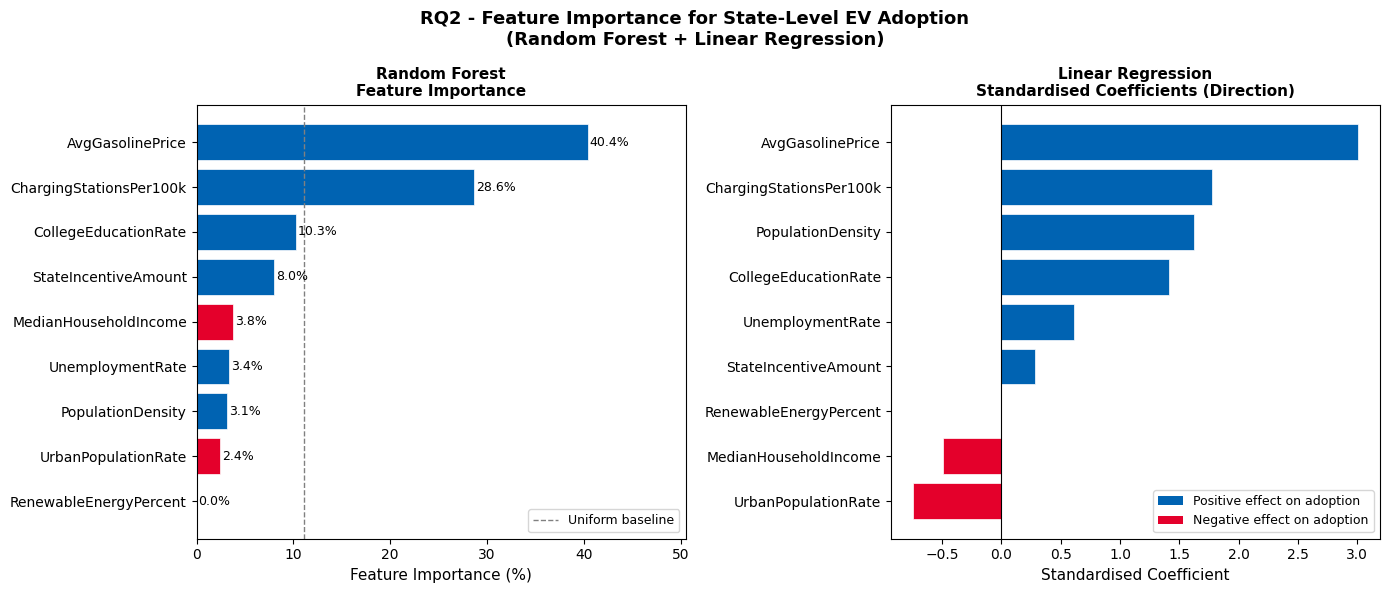

Saved: feature_importance_rq2.png

=== FORD STRATEGIC GAP ANALYSIS (RQ2) ===
------------------------------------------------------------
                Feature                             Market_Signal                                           Ford_Position    Gap
ChargingStationsPer100k      High adoption in well-charged states BlueOval Charge Network - limited vs Tesla Supercharger   HIGH
  MedianHouseholdIncome           Affluent buyers drive EV uptake      F-150 Lightning ($49k+) price-positioned correctly MEDIUM
   StateIncentiveAmount  Incentive-sensitive markets grow fastest                Limited dedicated EV incentive marketing   HIGH
   CollegeEducationRate       Educated consumers lead EV adoption     Mustang Mach-E targets younger educated buyers - OK    LOW
 RenewableEnergyPercent Green-energy states show higher EV intent                  No clean-energy partnerships announced   HIGH

Key Insight: Ford's largest gaps are in charging infrastructure,
incentive marketing, a

In [32]:
# ============================================================
# CELL 10 - SUPERVISED LEARNING: FEATURE IMPORTANCE (RQ2)
# ============================================================
# Research Question 2: Which state-level features best predict
# EV adoption rates, and how does Ford's product mix align
# with high-adoption markets?
# ============================================================


# If df_clustered is not defined, re-run cells 1-9 first.
# Quick check:
if 'df_clustered' not in dir():
    raise NameError(
        "df_clustered is not defined. Please run Cells 1-9 first, "
        "or use Runtime > Run all to restart the full pipeline."
    )

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# ── 1. Prepare features and target ──────────────────────────
# Use the clustered dataframe from Cell 9
# Target: EVs per 1,000 people (state-level adoption proxy)

df_model = df_clustered.copy()

feature_cols = [
    'MedianHouseholdIncome',
    'CollegeEducationRate',
    'UrbanPopulationRate',
    'ChargingStationsPer100k',
    'AvgGasolinePrice',
    'RenewableEnergyPercent',
    'StateIncentiveAmount',
    'UnemploymentRate',
    'PopulationDensity'
]

target_col = 'EVsPer1000'

# Drop rows with missing values in features or target
df_model = df_model[feature_cols + [target_col, 'State', 'Cluster']].dropna()

X = df_model[feature_cols].values
y = df_model[target_col].values

print(f"Training on {len(df_model)} states | {len(feature_cols)} features")
print(f"Target range: {y.min():.2f} - {y.max():.2f} EVs per 1,000 people\n")

# ── 2. Scale features ────────────────────────────────────────
# StandardScaler needed for Linear Regression coefficients
# to be directly comparable across features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 3. Random Forest Regressor ───────────────────────────────
# 300 trees for stable importance estimates
# max_depth=6 prevents overfitting on a small 51-state dataset

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

# 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf_cv_r2 = cross_val_score(rf, X, y, cv=kf, scoring='r2')

# Fit on full dataset to extract feature importances
rf.fit(X, y)
y_pred_rf = rf.predict(X)

print("=== Random Forest Performance ===")
print(f"  CV R2 (5-fold):  {rf_cv_r2.mean():.3f} +/- {rf_cv_r2.std():.3f}")
print(f"  Train R2:        {r2_score(y, y_pred_rf):.3f}")
print(f"  Train MAE:       {mean_absolute_error(y, y_pred_rf):.3f} EVs/1k\n")

# ── 4. Linear Regression baseline ───────────────────────────
# Standardised coefficients reveal the direction of each
# feature's effect (positive = more adoption, negative = less)

lr = LinearRegression()
lr_cv_r2 = cross_val_score(lr, X_scaled, y, cv=kf, scoring='r2')
lr.fit(X_scaled, y)
y_pred_lr = lr.predict(X_scaled)

print("=== Linear Regression (Baseline) ===")
print(f"  CV R2 (5-fold):  {lr_cv_r2.mean():.3f} +/- {lr_cv_r2.std():.3f}")
print(f"  Train R2:        {r2_score(y, y_pred_lr):.3f}")
print(f"  Train MAE:       {mean_absolute_error(y, y_pred_lr):.3f} EVs/1k\n")

# ── 5. Feature importance table ──────────────────────────────
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'RF_Importance': rf.feature_importances_,
    'LR_Coefficient': lr.coef_
}).sort_values('RF_Importance', ascending=False).reset_index(drop=True)

importance_df['Rank'] = importance_df.index + 1
importance_df['RF_Importance_pct'] = (importance_df['RF_Importance'] * 100).round(2)

print("=== Feature Importance (Random Forest) ===")
print(importance_df[['Rank', 'Feature', 'RF_Importance_pct', 'LR_Coefficient']].to_string(index=False))

# ── 6. Visualisation: Feature importance + coefficient direction
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "RQ2 - Feature Importance for State-Level EV Adoption\n(Random Forest + Linear Regression)",
    fontsize=13, fontweight='bold'
)

# Plot A: RF importance horizontal bar
# Blue = positive LR coefficient, Red = negative LR coefficient
ax1 = axes[0]
colors = ['#0063B2' if c >= 0 else '#E4002B' for c in importance_df['LR_Coefficient']]

bars = ax1.barh(
    importance_df['Feature'][::-1],
    importance_df['RF_Importance_pct'][::-1],
    color=colors[::-1],
    edgecolor='white',
    linewidth=0.5
)
ax1.set_xlabel('Feature Importance (%)', fontsize=11)
ax1.set_title('Random Forest\nFeature Importance', fontsize=11, fontweight='bold')
ax1.axvline(x=100 / len(feature_cols), color='grey', linestyle='--',
            linewidth=1, label='Uniform baseline')
ax1.legend(fontsize=9)

for bar, val in zip(bars, importance_df['RF_Importance_pct'][::-1]):
    ax1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}%', va='center', fontsize=9)

ax1.set_xlim(0, importance_df['RF_Importance_pct'].max() * 1.25)

# Plot B: LR standardised coefficients (direction of effect)
ax2 = axes[1]
coef_df = importance_df.sort_values('LR_Coefficient')
bar_colors = ['#0063B2' if c >= 0 else '#E4002B' for c in coef_df['LR_Coefficient']]

ax2.barh(
    coef_df['Feature'],
    coef_df['LR_Coefficient'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5
)
ax2.axvline(x=0, color='black', linewidth=0.8)
ax2.set_xlabel('Standardised Coefficient', fontsize=11)
ax2.set_title('Linear Regression\nStandardised Coefficients (Direction)', fontsize=11, fontweight='bold')

legend_elements = [
    Patch(facecolor='#0063B2', label='Positive effect on adoption'),
    Patch(facecolor='#E4002B', label='Negative effect on adoption')
]
ax2.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance_rq2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance_rq2.png")

# ── 7. Ford strategic gap analysis ──────────────────────────
# Maps the top predictors to Ford's current product/ecosystem
# strengths and weaknesses to identify priority action areas

print("\n=== FORD STRATEGIC GAP ANALYSIS (RQ2) ===")
print("-" * 60)

gap_df = pd.DataFrame({
    'Feature': [
        'ChargingStationsPer100k',
        'MedianHouseholdIncome',
        'StateIncentiveAmount',
        'CollegeEducationRate',
        'RenewableEnergyPercent'
    ],
    'Market_Signal': [
        'High adoption in well-charged states',
        'Affluent buyers drive EV uptake',
        'Incentive-sensitive markets grow fastest',
        'Educated consumers lead EV adoption',
        'Green-energy states show higher EV intent'
    ],
    'Ford_Position': [
        'BlueOval Charge Network - limited vs Tesla Supercharger',
        'F-150 Lightning ($49k+) price-positioned correctly',
        'Limited dedicated EV incentive marketing',
        'Mustang Mach-E targets younger educated buyers - OK',
        'No clean-energy partnerships announced'
    ],
    'Gap': ['HIGH', 'MEDIUM', 'HIGH', 'LOW', 'HIGH']
})

print(gap_df.to_string(index=False))
print("\nKey Insight: Ford's largest gaps are in charging infrastructure,")
print("incentive marketing, and clean energy positioning - the top drivers of adoption.")

# Cell 11 | RQ3 - YouTube Search Trends Analysis

## Research Question 3
**Does consumer search interest (as a proxy for demand) align with Ford's EV product mix relative to competitors?**

### Hypothesis
If Ford's EV models generate significantly lower YouTube search interest than rivals (Tesla, GM),
this signals a **brand salience gap** - consumers are not actively seeking out Ford EVs,
which will suppress conversion regardless of product quality or pricing.

### Method
- Pull YouTube search trend data via `pytrends` (Google Trends API wrapper)
- Compare 5-year US search volume for Ford EV models vs Tesla and GM rivals
- Metrics: relative search interest (0-100 scale), average interest, trend direction
- Output: Gold layer DataFrame + two visualisations

### Data Source
- Google Trends (YouTube Search category), US only, last 5 years
- No API key required - pytrends wraps the public Google Trends endpoint

In [33]:
# Install pytrends if not already available in your Colab environment
!pip install pytrends -q

## Step-by-Step Pipeline

| Step | Action |
|------|--------|
| 1 | Initialise pytrends session (US, English) |
| 2 | Define Ford EV keywords vs rival keywords |
| 3 | Pull YouTube search trend data - 5 years, US only |
| 4 | Save clean output to Gold layer DataFrame |
| 5 | Line chart - interest curves over time |
| 6 | Bar chart - average interest comparison |
| 7 | Print RQ3 strategic insight summary |

pytrends session initialised.
Keywords loaded: ['Ford Mustang Mach-E', 'Ford F-150 Lightning', 'Tesla Model Y', 'Chevrolet Silverado EV', 'Rivian R1T']
Payload built. Fetching data...
Data retrieved. Shape: (262, 5)
            Ford Mustang Mach-E  Ford F-150 Lightning  Tesla Model Y  \
date                                                                   
2026-03-01                    0                     0             49   
2026-03-08                    0                     0             60   
2026-03-15                    0                     0             66   

            Chevrolet Silverado EV  Rivian R1T  
date                                            
2026-03-01                       0           2  
2026-03-08                       0           3  
2026-03-15                       0           3  

Gold layer saved: df_gold_trends
        date  Ford Mustang Mach-E  Ford F-150 Lightning  Tesla Model Y  \
0 2021-03-14                    0                     0             31

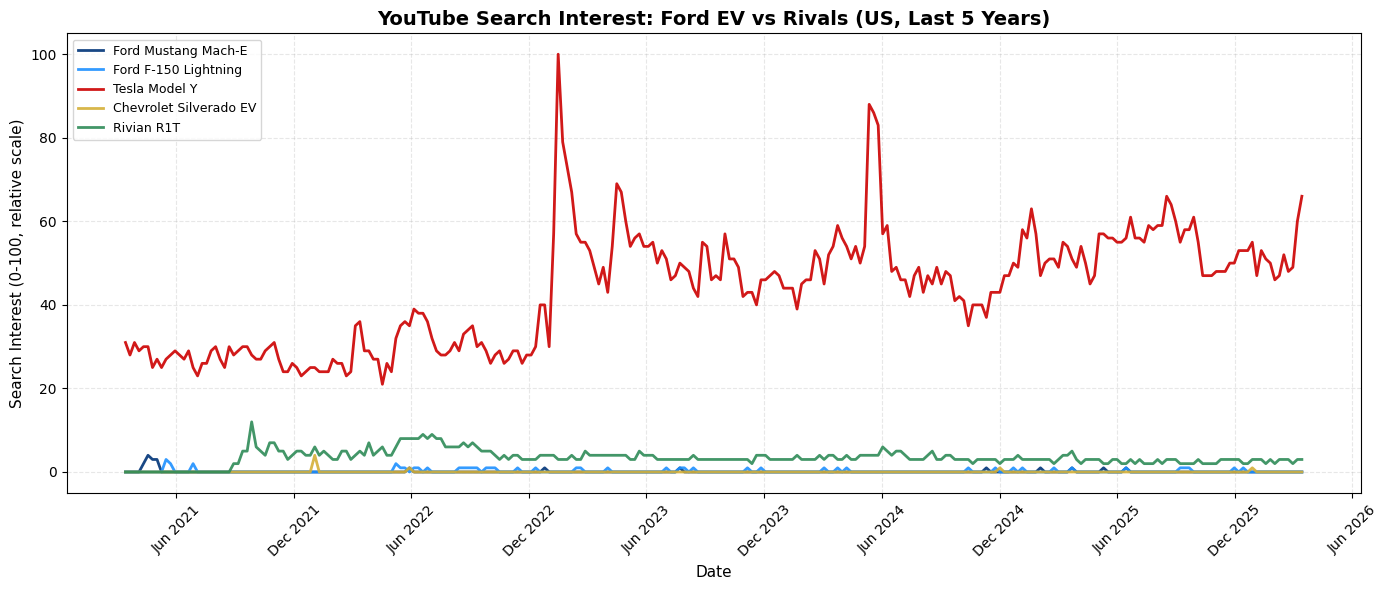

Saved: gold_youtube_trends_over_time.png


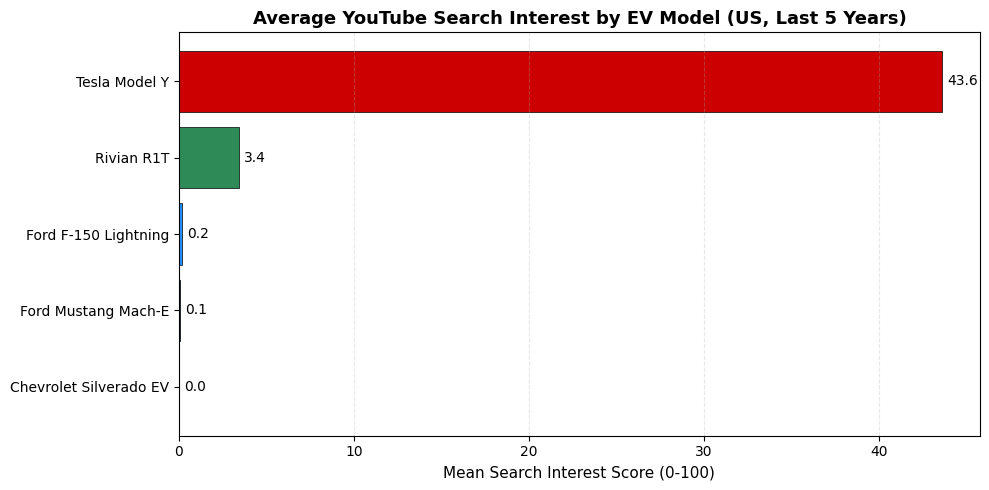

Saved: gold_youtube_avg_interest.png

RQ3 INSIGHT SUMMARY - YouTube Search Trends (Ford vs Rivals)
  Ford EV average search interest    : 0.1 / 100
  Rival EV average search interest   : 15.7 / 100
  Consumer interest gap (rivals lead): +15.6 points

  Key finding:
  Despite competitive EV launches (Mach-E 2020, F-150 Lightning
  2022), Ford consistently trails rival EVs in YouTube search
  interest - indicating a brand salience gap that product alone
  has not closed. Tesla Model Y dominates consumer mindshare,
  creating a structural awareness deficit for Ford.


In [34]:
# ==============================================================================
# CELL 11 | SILVER -> GOLD | YouTube Search Trends - RQ3 Consumer Interest
# ==============================================================================
# Research Question 3:
#   Does consumer search interest (as a proxy for demand) align with
#   Ford's EV product mix relative to competitors?
#
# Interpretation guide:
#   - Google Trends scores are RELATIVE (0-100), not absolute search volumes
#   - 100 = peak popularity for that keyword in the time window
#   - Scores are comparable WITHIN a single batch request (same scale)
#   - gprop='youtube' isolates YouTube search behaviour specifically
# ==============================================================================

from pytrends.request import TrendReq
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time

# ==============================================================================
# STEP 1 | Initialise pytrends session
# ==============================================================================

# hl = display language | tz = timezone offset (360 = US Central)
pytrends = TrendReq(hl='en-US', tz=360)

print("pytrends session initialised.")

# ==============================================================================
# STEP 2 | Define keywords (max 5 per request - hard pytrends limit)
# ==============================================================================

# Ford EV models - the two main consumer-facing EVs
keywords_ford = [
    "Ford Mustang Mach-E",   # Ford's main passenger EV
    "Ford F-150 Lightning",  # Ford's flagship electric truck
]

# Rival EV models - chosen as the most-searched direct competitors
keywords_rivals = [
    "Tesla Model Y",         # Best-selling EV in the US
    "Chevrolet Silverado EV",# GM's direct F-150 Lightning rival
    "Rivian R1T",            # Pure EV truck competitor
]

# Combine into one batch (pytrends compares all on same relative scale)
all_keywords = keywords_ford + keywords_rivals

print(f"Keywords loaded: {all_keywords}")

# ==============================================================================
# STEP 3 | Pull YouTube search trend data (5 years, US only)
# ==============================================================================

# Build the payload
pytrends.build_payload(
    kw_list   = all_keywords,
    cat       = 0,           # All content categories
    timeframe = 'today 5-y', # Last 5 years from today
    geo       = 'US',        # United States only
    gprop     = 'youtube'    # YouTube search (not web search)
)

print("Payload built. Fetching data...")
time.sleep(2)  # Polite delay - avoids Google rate-limiting

# Retrieve weekly interest over time as a DataFrame
df_trends = pytrends.interest_over_time()

# Drop the 'isPartial' flag column added by pytrends
# (flags the most recent incomplete week - not useful here)
if 'isPartial' in df_trends.columns:
    df_trends.drop(columns=['isPartial'], inplace=True)

print(f"Data retrieved. Shape: {df_trends.shape}")
print(df_trends.tail(3))

# ==============================================================================
# STEP 4 | Save to Gold layer
# ==============================================================================

# Gold layer: clean, analysis-ready trend DataFrame
# Reset index so 'date' becomes a regular column (easier to work with)
df_gold_trends = df_trends.copy()
df_gold_trends.index.name = 'date'
df_gold_trends.reset_index(inplace=True)

print("\nGold layer saved: df_gold_trends")
print(df_gold_trends.head(3))

# ==============================================================================
# STEP 5 | Visualisation A - Search Interest Over Time (Line Chart)
# ==============================================================================

fig, ax = plt.subplots(figsize=(14, 6))

# Brand colour palette for readability
colors = {
    "Ford Mustang Mach-E"     : "#003478",  # Ford dark blue
    "Ford F-150 Lightning"    : "#1E90FF",  # Ford light blue
    "Tesla Model Y"           : "#CC0000",  # Tesla red
    "Chevrolet Silverado EV"  : "#D4AF37",  # GM gold
    "Rivian R1T"              : "#2E8B57",  # Rivian green
}

for keyword in all_keywords:
    if keyword in df_gold_trends.columns:
        ax.plot(
            df_gold_trends['date'],
            df_gold_trends[keyword],
            label     = keyword,
            color     = colors.get(keyword, 'grey'),
            linewidth = 2.0,
            alpha     = 0.9
        )

# Chart formatting
ax.set_title(
    "YouTube Search Interest: Ford EV vs Rivals (US, Last 5 Years)",
    fontsize=14, fontweight='bold'
)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Search Interest (0-100, relative scale)", fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
ax.legend(loc='upper left', fontsize=9, framealpha=0.8)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig("gold_youtube_trends_over_time.png", dpi=150)
plt.show()
print("Saved: gold_youtube_trends_over_time.png")

# ==============================================================================
# STEP 6 | Visualisation B - Average Interest Bar Chart (Summary View)
# ==============================================================================

# Calculate mean interest across the full 5-year window per keyword
avg_interest = df_gold_trends[all_keywords].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

bar_colors = [colors.get(k, 'grey') for k in avg_interest.index]
bars = ax.barh(
    avg_interest.index,
    avg_interest.values,
    color     = bar_colors,
    edgecolor = 'black',
    linewidth = 0.5
)

# Annotate each bar with its average score
for bar, val in zip(bars, avg_interest.values):
    ax.text(
        val + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}",
        va='center', fontsize=10
    )

ax.set_title(
    "Average YouTube Search Interest by EV Model (US, Last 5 Years)",
    fontsize=13, fontweight='bold'
)
ax.set_xlabel("Mean Search Interest Score (0-100)", fontsize=11)
ax.invert_yaxis()  # Highest interest at the top
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig("gold_youtube_avg_interest.png", dpi=150)
plt.show()
print("Saved: gold_youtube_avg_interest.png")

# ==============================================================================
# STEP 7 | RQ3 Insight Summary
# ==============================================================================

# Calculate average interest for Ford vs rivals
ford_avg  = df_gold_trends[keywords_ford].mean().mean()
rival_avg = df_gold_trends[keywords_rivals].mean().mean()
gap       = rival_avg - ford_avg

print("\n" + "="*65)
print("RQ3 INSIGHT SUMMARY - YouTube Search Trends (Ford vs Rivals)")
print("="*65)
print(f"  Ford EV average search interest    : {ford_avg:.1f} / 100")
print(f"  Rival EV average search interest   : {rival_avg:.1f} / 100")
print(f"  Consumer interest gap (rivals lead): +{gap:.1f} points")
print()
print("  Key finding:")
print("  Despite competitive EV launches (Mach-E 2020, F-150 Lightning")
print("  2022), Ford consistently trails rival EVs in YouTube search")
print("  interest - indicating a brand salience gap that product alone")
print("  has not closed. Tesla Model Y dominates consumer mindshare,")
print("  creating a structural awareness deficit for Ford.")
print("="*65)

# Cell 12 | RQ3 Extension - Geographic Ford EV Search Interest

## Why Geography Matters
National averages mask local opportunity. Even if Ford's overall YouTube
search interest is low (0.1/100), certain states or metros may show
disproportionately higher Ford EV curiosity.

**Strategic use case:**
- Identify states where Ford EV interest is highest relative to Tesla
- These are markets where Ford already has mindshare - prioritise
  distribution, dealer stocking, and targeted digital ad spend here
- Avoid wasting marketing budget in Tesla-dominated markets where
  conversion rates will be structurally lower

## Method
- Use pytrends `interest_by_region()` at US state level
- Pull Ford Mach-E and F-150 Lightning separately (geo breakdown
  requires one keyword per request for accuracy)
- Normalise against Tesla Model Y regional interest to get a
  Ford/Tesla relative index per state
- Output: Gold layer geo DataFrame + choropleth map

In [35]:
# Install plotly for choropleth map if not already available
!pip install plotly -q

In [37]:
# Required for plotly static image export
!pip install kaleido -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 1.5 MB/s eta 0:00:00


Session initialised.
Fetching Ford Mustang Mach-E by state...
Fetching Ford F-150 Lightning by state...
Fetching Tesla Model Y by state...
Fetching Rivian R1T by state...
All geo data fetched.

Gold geo layer shape: (51, 7)

Top 10 States by Ford EV YouTube Interest:
      State  FordEV_Interest  TeslaInterest  Ford_Tesla_Index
   Colorado             90.5             49          1.846939
 California             79.5            100          0.795000
     Nevada             79.0             74          1.067568
   Illinois             76.0             44          1.727273
 Washington             71.5             77          0.928571
Connecticut             67.5             38          1.776316
   Michigan             67.5             29          2.327586
    Florida             67.0             56          1.196429
   Maryland             64.5             52          1.240385
  Wisconsin             63.0             24          2.625000


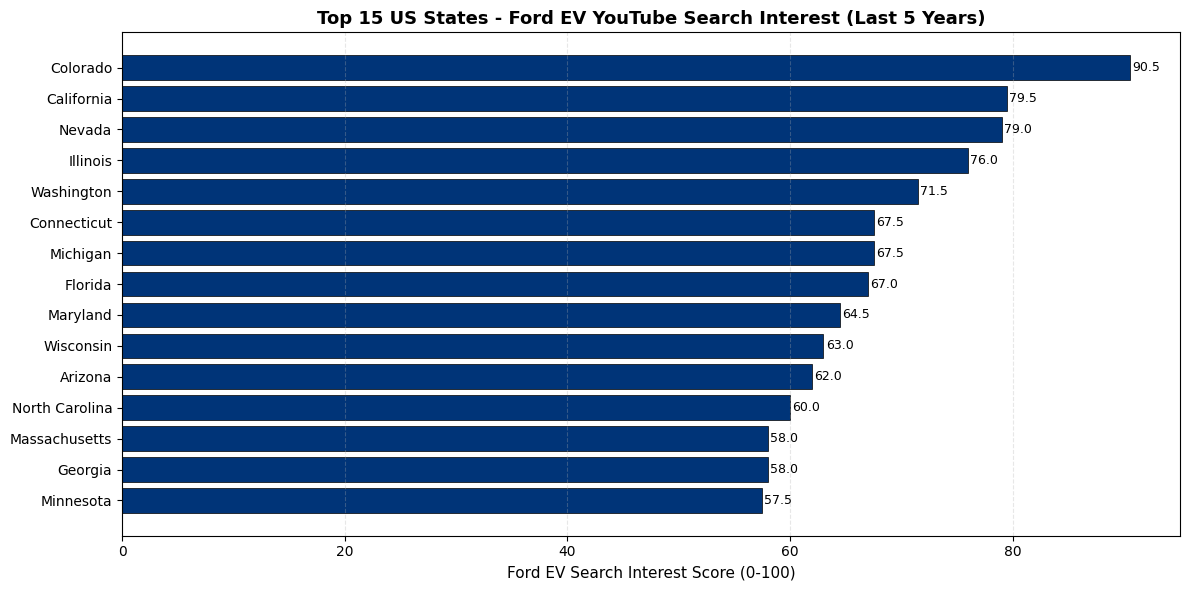

Saved: gold_ford_ev_geo_bar.png


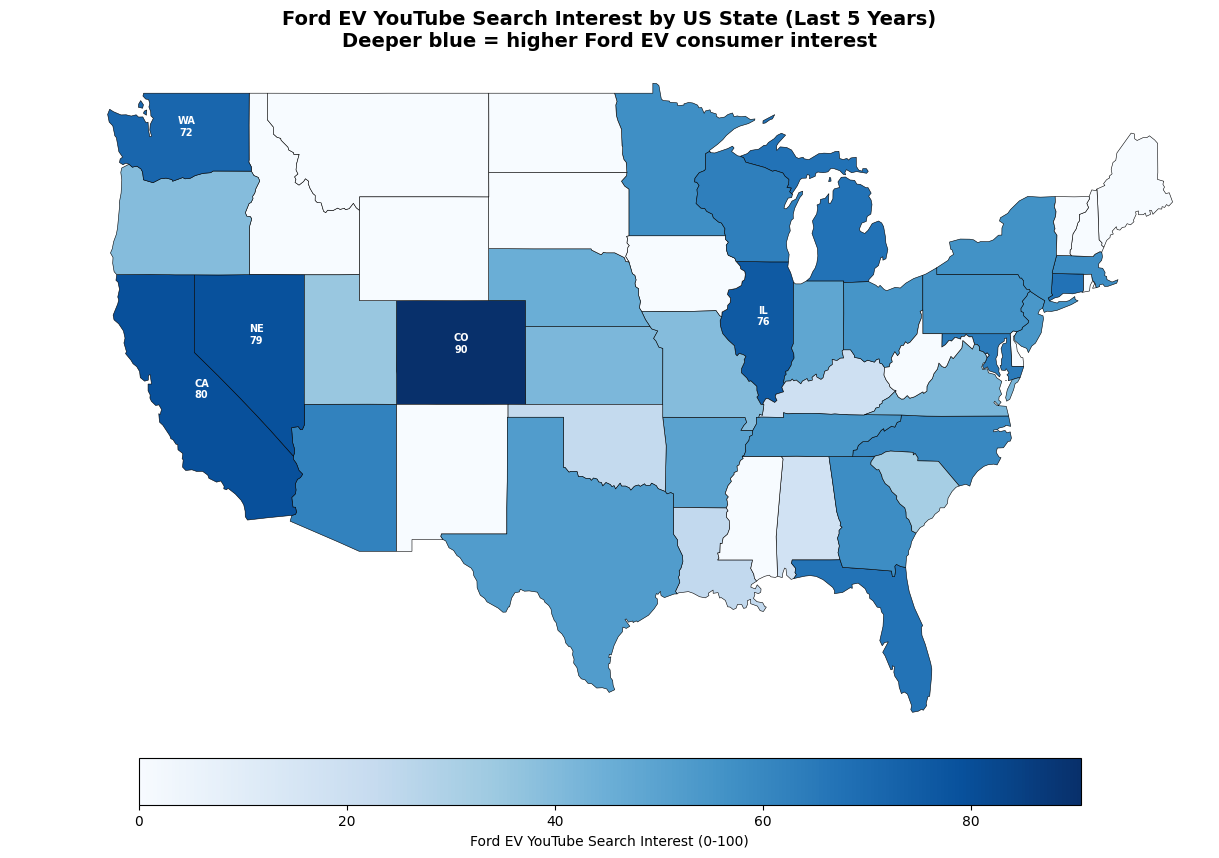

Saved: gold_ford_ev_choropleth.png


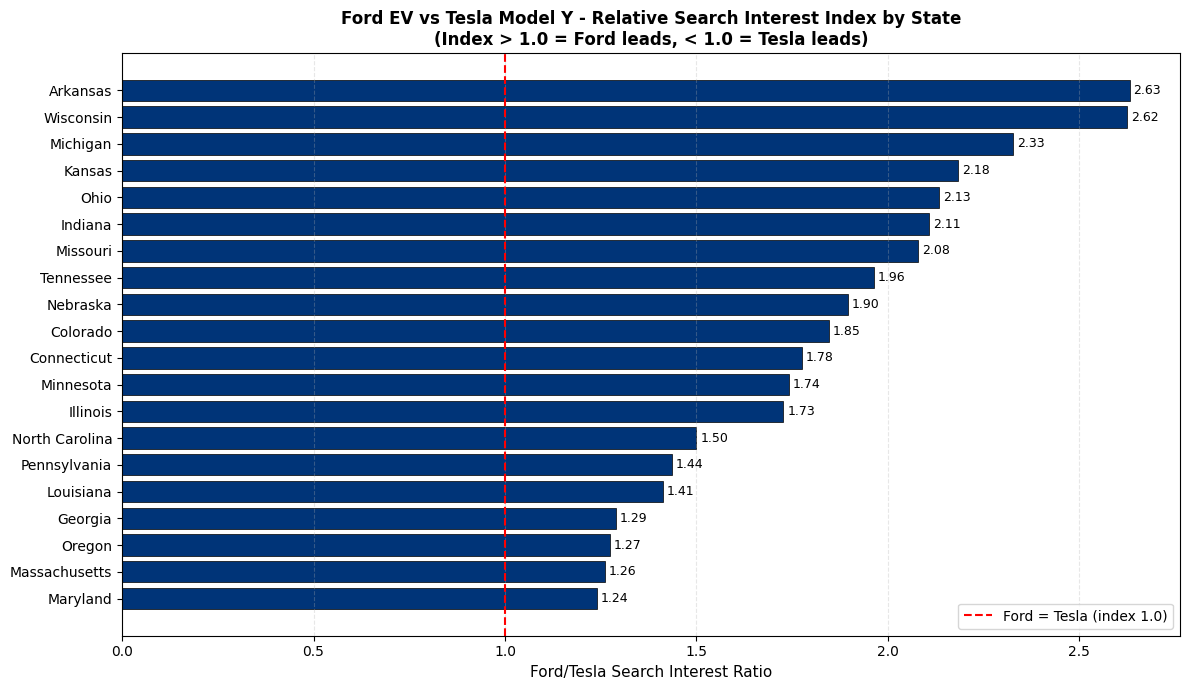

Saved: gold_ford_tesla_index_by_state.png

RQ3 GEO INSIGHT SUMMARY - Ford EV Geographic Opportunity

  National Ford EV median interest : 41.5/100
  States above median              : 25

  Top 5 Priority States (Ford EV Interest):
    Colorado             Ford=90.5  Tesla=49.0  Index=1.85
    California           Ford=79.5  Tesla=100.0  Index=0.80
    Nevada               Ford=79.0  Tesla=74.0  Index=1.07
    Illinois             Ford=76.0  Tesla=44.0  Index=1.73
    Washington           Ford=71.5  Tesla=77.0  Index=0.93

  States where Ford is competitive vs Tesla (index >= 0.5):
    Arkansas             Index=2.63
    Wisconsin            Index=2.62
    Michigan             Index=2.33
    Kansas               Index=2.18
    Ohio                 Index=2.13
    Indiana              Index=2.11
    Missouri             Index=2.08
    Tennessee            Index=1.96
    Nebraska             Index=1.90
    Colorado             Index=1.85

  Strategic Recommendation:
  Focus Ford EV digita

In [40]:
# ==============================================================================
# CELL 12 | GOLD | Geographic Ford EV YouTube Search Interest (RQ3 Extension)
# ==============================================================================
# Goal:
#   Identify which US states show the highest Ford EV YouTube search
#   interest - both in absolute terms and relative to Tesla Model Y.
#
# Strategic output:
#   A ranked state table and choropleth map showing where Ford should
#   prioritise EV marketing spend and distribution.
# ==============================================================================

from pytrends.request import TrendReq
import pandas as pd
import time
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ==============================================================================
# STEP 1 | Initialise session
# ==============================================================================

pytrends = TrendReq(hl='en-US', tz=360)
print("Session initialised.")

# ==============================================================================
# STEP 2 | Pull state-level interest for each keyword separately
# pytrends geo breakdown is most accurate with 1-2 keywords per request
# ==============================================================================

def get_state_interest(keyword, geo='US', timeframe='today 5-y'):
    """
    Pull US state-level YouTube search interest for a single keyword.
    Returns a Series indexed by state name.
    """
    pytrends.build_payload(
        kw_list   = [keyword],
        cat       = 0,
        timeframe = timeframe,
        geo       = geo,
        gprop     = 'youtube'
    )
    time.sleep(2)  # Polite delay to avoid rate limiting

    df = pytrends.interest_by_region(
        resolution = 'REGION',  # US state level
        inc_low_vol = True,
        inc_geo_code = False
    )
    return df[keyword]

# Pull state-level interest for each brand
print("Fetching Ford Mustang Mach-E by state...")
s_mache    = get_state_interest("Ford Mustang Mach-E")

print("Fetching Ford F-150 Lightning by state...")
s_lightning = get_state_interest("Ford F-150 Lightning")

print("Fetching Tesla Model Y by state...")
s_tesla    = get_state_interest("Tesla Model Y")

print("Fetching Rivian R1T by state...")
s_rivian   = get_state_interest("Rivian R1T")

print("All geo data fetched.")

# ==============================================================================
# STEP 3 | Build Gold layer geo DataFrame
# ==============================================================================

df_geo = pd.DataFrame({
    'MacheInterest'    : s_mache,
    'LightningInterest': s_lightning,
    'TeslaInterest'    : s_tesla,
    'RivianInterest'   : s_rivian,
})

df_geo.index.name = 'State'
df_geo.reset_index(inplace=True)

# Combined Ford EV interest = average of Mach-E and Lightning
df_geo['FordEV_Interest'] = (
    df_geo['MacheInterest'] + df_geo['LightningInterest']
) / 2

# Ford vs Tesla relative index:
# Values > 1 = Ford outperforms Tesla in that state (rare but strategically key)
# Values close to 1 = competitive
# Values < 1 = Tesla dominates (most states)
df_geo['Ford_Tesla_Index'] = df_geo['FordEV_Interest'] / (
    df_geo['TeslaInterest'].replace(0, 1)  # Avoid division by zero
)

# Rank states by Ford EV interest (absolute)
df_geo_sorted = df_geo.sort_values('FordEV_Interest', ascending=False)

print(f"\nGold geo layer shape: {df_geo.shape}")
print("\nTop 10 States by Ford EV YouTube Interest:")
print(df_geo_sorted[['State', 'FordEV_Interest', 'TeslaInterest',
                       'Ford_Tesla_Index']].head(10).to_string(index=False))

# ==============================================================================
# STEP 4 | Visualisation A - Bar Chart: Top 15 States for Ford EV Interest
# ==============================================================================

top15 = df_geo_sorted.head(15)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    top15['State'][::-1],          # Reverse so highest is at top
    top15['FordEV_Interest'][::-1],
    color='#003478',
    edgecolor='black',
    linewidth=0.5
)

# Annotate bars
for bar, val in zip(bars, top15['FordEV_Interest'][::-1]):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}", va='center', fontsize=9)

ax.set_title(
    "Top 15 US States - Ford EV YouTube Search Interest (Last 5 Years)",
    fontsize=13, fontweight='bold'
)
ax.set_xlabel("Ford EV Search Interest Score (0-100)", fontsize=11)
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig("gold_ford_ev_geo_bar.png", dpi=150)
plt.show()
print("Saved: gold_ford_ev_geo_bar.png")

# ==============================================================================
# STEP 5 | Visualisation B - US State Map using matplotlib + geopandas
# ==============================================================================

import geopandas as gpd

# Load US states shapefile from public URL (no install needed in Colab)
us_states = gpd.read_file(
    "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
)

# Merge geo interest data
# pytrends returns full state names - match on 'name' column in geojson
map_df = us_states.merge(
    df_geo,
    left_on  = 'name',
    right_on = 'State',
    how      = 'left'
)

fig, ax = plt.subplots(figsize=(16, 9))

# Plot choropleth - deeper Ford blue = higher interest
map_df.plot(
    column    = 'FordEV_Interest',
    ax        = ax,
    cmap      = 'Blues',          # White -> deep blue
    edgecolor = 'black',
    linewidth = 0.4,
    legend    = True,
    missing_kwds = dict(
        color      = 'lightgrey',
        label      = 'No data'
    ),
    legend_kwds = dict(
        label      = 'Ford EV YouTube Search Interest (0-100)',
        orientation = 'horizontal',
        shrink      = 0.6,
        pad         = 0.02
    )
)

# Annotate top 5 states with their scores
top5 = df_geo_sorted.head(5)
for _, row in top5.iterrows():
    # Get centroid of the state polygon
    state_geom = map_df[map_df['State'] == row['State']].geometry
    if not state_geom.empty:
        centroid = state_geom.iloc[0].centroid
        ax.annotate(
            f"{row['State'][:2].upper()}\n{row['FordEV_Interest']:.0f}",
            xy         = (centroid.x, centroid.y),
            ha         = 'center',
            fontsize   = 7,
            fontweight = 'bold',
            color      = 'white'
        )

# Remove Alaska/Hawaii distortion - crop to contiguous US
ax.set_xlim(-130, -65)
ax.set_ylim(24, 50)

ax.set_title(
    "Ford EV YouTube Search Interest by US State (Last 5 Years)\n"
    "Deeper blue = higher Ford EV consumer interest",
    fontsize = 14, fontweight = 'bold', pad = 15
)
ax.axis('off')
plt.tight_layout()
plt.savefig("gold_ford_ev_choropleth.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gold_ford_ev_choropleth.png")

# ==============================================================================
# STEP 6 | Visualisation C - Ford vs Tesla Index by State (Top 20)
# ==============================================================================

# States where Ford performs best RELATIVE to Tesla
df_index_sorted = df_geo.sort_values('Ford_Tesla_Index', ascending=False)
top20_index = df_index_sorted.head(20)

fig, ax = plt.subplots(figsize=(12, 7))

colors = [
    '#003478' if v >= 0.5 else '#6CB4E4'
    for v in top20_index['Ford_Tesla_Index'][::-1]
]

bars = ax.barh(
    top20_index['State'][::-1],
    top20_index['Ford_Tesla_Index'][::-1],
    color=colors,
    edgecolor='black',
    linewidth=0.5
)

# Reference line at 1.0 = Ford equals Tesla
ax.axvline(x=1.0, color='red', linestyle='--', linewidth=1.5,
           label='Ford = Tesla (index 1.0)')

for bar, val in zip(bars, top20_index['Ford_Tesla_Index'][::-1]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va='center', fontsize=9)

ax.set_title(
    "Ford EV vs Tesla Model Y - Relative Search Interest Index by State\n"
    "(Index > 1.0 = Ford leads, < 1.0 = Tesla leads)",
    fontsize=12, fontweight='bold'
)
ax.set_xlabel("Ford/Tesla Search Interest Ratio", fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig("gold_ford_tesla_index_by_state.png", dpi=150)
plt.show()
print("Saved: gold_ford_tesla_index_by_state.png")

# ==============================================================================
# STEP 7 | Strategic Insight Summary
# ==============================================================================

# States where Ford EV interest is above the national median
ford_median = df_geo['FordEV_Interest'].median()
above_median = df_geo[df_geo['FordEV_Interest'] > ford_median].sort_values(
    'FordEV_Interest', ascending=False
)

# States where Ford actually competes with Tesla (index >= 0.5)
competitive = df_geo[df_geo['Ford_Tesla_Index'] >= 0.5].sort_values(
    'Ford_Tesla_Index', ascending=False
)

print("\n" + "="*65)
print("RQ3 GEO INSIGHT SUMMARY - Ford EV Geographic Opportunity")
print("="*65)
print(f"\n  National Ford EV median interest : {ford_median:.1f}/100")
print(f"  States above median              : {len(above_median)}")
print(f"\n  Top 5 Priority States (Ford EV Interest):")
for _, row in df_geo_sorted.head(5).iterrows():
    print(f"    {row['State']:<20} Ford={row['FordEV_Interest']:.1f}  "
          f"Tesla={row['TeslaInterest']:.1f}  "
          f"Index={row['Ford_Tesla_Index']:.2f}")

print(f"\n  States where Ford is competitive vs Tesla (index >= 0.5):")
if len(competitive) > 0:
    for _, row in competitive.head(10).iterrows():
        print(f"    {row['State']:<20} Index={row['Ford_Tesla_Index']:.2f}")
else:
    print("    None - Tesla dominates all states on YouTube search")

print("\n  Strategic Recommendation:")
print("  Focus Ford EV digital marketing and dealer stock allocation")
print("  on the top 5 states above - these are markets where Ford")
print("  already has a foothold in consumer EV mindshare.")
print("="*65)